In [56]:
import torch
import numpy as np
import gymnasium as gym

import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
from pyvirtualdisplay import Display
import gymnasium_robotics
import metaworld
gym.register_envs(gymnasium_robotics)

import os
os.environ['MUJOCO_GL'] = 'egl'
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../src')))
from src.data_gen.gen_fetch import name_to_env, env_to_aspace, process_image, meta_world_envs, metaworld_cam_name
from src.utils import set_seed

# disp = Display(visible=0, size=(480, 480))
# disp.start()
# os.environ["DISPLAY"] = "99"
rand_seed=123
device = torch.device(f"cuda:{2}" if torch.cuda.is_available() else "cpu")
from pathlib import Path
os.chdir(Path(os.getcwd()).parent.parent)

In [72]:
envs_to_render = ['coffee', 'door', 'faucet'] # 'button', 'drawer', 
affordance_action_configs = [
    '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/coffee/coffee_pixel_0/eval_states_11.pt',
    '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/door/door_pixel_0/eval_states_1.pt',
    '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/faucet/faucet_pixel_0/eval_states_0.pt',
    ]

# states: list of 3 tensors/arrays; cols: [x, y, z, gripper, x_obj, y_obj, z_obj, reward, xdot, ydot, zdot, gripper_vel, contact]
actions = {
    'coffee': {},
    'door': {},
    'faucet': {},
}
for aff_action, env_name in zip(affordance_action_configs, envs_to_render):
    saved_states = torch.load(aff_action)
    actions.update({env_name: {'actions': saved_states[:, 8:12], 'seed': aff_action.split('_')[-1][0]}})

actions['coffee']['actions'] = actions['coffee']['actions'][:40].cpu().numpy()
actions['door']['actions'] = actions['door']['actions'][:68].cpu().numpy()
actions['faucet']['actions'] = actions['faucet']['actions'][:32].cpu().numpy()

FileNotFoundError: [Errno 2] No such file or directory: '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/faucet/faucet_pixel_0/eval_states_0.pt'

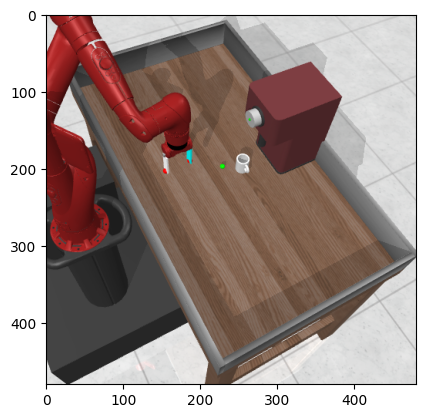

In [75]:
env = gym.make('Meta-World/MT1', env_name=name_to_env["coffee"], render_mode='rgb_array', camera_name='corner3')
obs, _ = env.reset()
plt.imshow(np.rot90(env.render(), k=2))
plt.savefig("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/coffee_start.png")
plt.show()

In [58]:
from src.model.rssm import RSSME2C

def kl_diag_gaussian(mu_q, log_var_q, mu_p, log_var_p):
    # Same exact function as RSSMLoss.kl_divergence
    return 0.5 * (
        log_var_p - log_var_q
        + (torch.exp(log_var_q) + (mu_q - mu_p) ** 2) / torch.exp(log_var_p)
        - 1
    ).sum(dim=-1)

In [59]:
def rollout_info_gain_decoded_batch(model: RSSME2C, window, action_samples, t0_dist):
    with torch.no_grad(), torch.cuda.amp.autocast():
        B, T, A = action_samples.shape
        if t0_dist is None:
            mu_q, log_var_q, zs = model.encode_posterior(window)
        else:
            mu_q, log_var_q, zs = t0_dist
        total_kl = torch.zeros(B, device=model.device)

        h = torch.zeros(model.num_layers, B, model.deterministic_size, device=model.device)
        z = zs[:, -1] # take last timestep
        mu_q = mu_q[:, -1] # take last timestep
        log_var_q = log_var_q[:, -1] # take last timestep

        for t in range(T):
            action = action_samples[:, t]
            # Prior from dynamics
            h, z_prior, mu_p, log_var_p = model.rssm_step(
                h, z.unsqueeze(1), action
            )
            # Decode prior to observation space
            if model.output_uncertainty:
                x_pred, x_pred_uncertainty = model.decoder(z_prior)
            else:
                x_pred = model.decoder(z_prior)
            if model.past_length > 1:
                window_frames = window[:, 1:]   # drop first frame
                window = torch.cat([window_frames, x_pred.unsqueeze(1).detach()], dim=1)
            else:
                window = x_pred.detach()  # past_length==1, just use pred image
            mu_post, log_var_post, zs = model.encode_posterior(window)
            z = zs[:, -1]
            mu_post = mu_post[:, -1]
            log_var_post = log_var_post[:, -1]

            total_kl += kl_diag_gaussian(mu_post, log_var_post, mu_p, log_var_p).mean(dim=-1)
            # to compare over t0, comment this out
            mu_q = mu_post
            log_var_q = log_var_post

            # update belief <-- happens inherently with model.encode_posterior
            zs = model.reparameterize(mu_post, log_var_post)

        return total_kl # / T # Average info gain per step

def sample_cem(model, frame_buffer, mu=None, sigma=None):
    # Initialize CEM distribution
    plan_horizon = 8
    cem_iters = 200
    num_action_samples = 200
    mu = torch.stack([torch.from_numpy(np.array([0.04, 0.04, 0.0, 0.0])).to(model.device, torch.float32) for _ in range(plan_horizon)], dim=0)
    sigma = 0.2 * torch.ones_like(mu, device=model.device)
    act_low = 5.0 * torch.as_tensor(env.action_space.low, device=model.device, dtype=torch.float32)
    act_high = 5.0 * torch.as_tensor(env.action_space.high, device=model.device, dtype=torch.float32)
    for _ in range(cem_iters):
        costs = torch.zeros(num_action_samples, device=model.device)
        action_samples = torch.normal(mu.unsqueeze(0), sigma.unsqueeze(0)).expand(num_action_samples, -1, -1)
        # Clip to action space bounds
        action_samples = torch.clamp(action_samples, act_low, act_high)
        
        # Evaluate information gain for each sequence
        # window = torch.stack(frame_buffer[-self.past_length:], dim=0).unsqueeze(0).to(self.device)
        window = torch.stack(frame_buffer[-3:], dim=0).unsqueeze(0).to(model.device).repeat(num_action_samples, 1, 1, 1, 1)
        mu_prior, log_var_prior, z_prior = model.encode_posterior(window)
        costs = rollout_info_gain_decoded_batch(model, window, action_samples, t0_dist=(mu_prior, log_var_prior, z_prior))

        
        # Select elite sequences
        num_elites = max(1, int(0.2 * num_action_samples))
        elite_idxs = costs.argsort()[-num_elites:]      # TODO: Is sorting afterwards the most optimal way?
        elite_seqs = action_samples[elite_idxs]
        
        # Update CEM distribution parameters
        # take mean and stddev across elite sequences at each time step
        new_mu = torch.stack([torch.mean(torch.stack([seq[t] for seq in elite_seqs], dim=0), dim=0) for t in range(plan_horizon)], dim=0)
        # new_sigma = torch.stack([torch.std(torch.stack([seq[t] for seq in elite_seqs], dim=0), dim=0) for t in range(self.plan_horizon)], dim=0)
        new_sigma = 1 / len(new_mu - 1) * torch.stack([torch.sum(torch.stack([torch.sqrt((seq[t] - new_mu[t])**2) for seq in elite_seqs], dim=0), dim=0) for t in range(plan_horizon)], dim=0)
        alpha = 0.1
        mu = alpha * mu + (1 - alpha) * new_mu
        mu = torch.clamp(mu, act_low, act_high)
        sigma = torch.nan_to_num(alpha * sigma + (1 - alpha) * new_sigma, nan=0.0)
        sigma = torch.clamp(sigma, min=0.2)
    
    mu[:-1] = mu[1:].clone()  # shift mean sequence left
    sigma[:-1] = sigma[1:].clone()

    return mu, costs, sigma, action_samples

def select_information_action(model, frame_buffer, mu=None, sigma=None):
    mu, costs, sigma = sample_cem(model, frame_buffer, mu=mu, sigma=sigma)
    return mu, costs, sigma

In [69]:
from src.e2c import E2CDataset
from src.trainer import ClosedLoopInformativeTrainer
import yaml

def posixpath_constructor(loader, node):
    seq = loader.construct_sequence(node)
    return Path(*seq)

# define yaml_safe load constructor to handle PosixPath
yaml.SafeLoader.add_constructor(
    "tag:yaml.org,2002:python/object/apply:pathlib.PosixPath",
    posixpath_constructor,
)

with open("/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/coffee/coffee_pixel_20/config.yaml", 'r') as f:
    config = yaml.safe_load(f)
config['vae']['in_image_shape'] = (9, 64, 64)
config['vae']['out_image_shape'] = (3, *config['vae']['in_image_shape'][1:])     
model = RSSME2C(
    enc_latent_size=config['vae']['enc_latent_size'],
            stochastic_size=config['trans']['stochastic_size'],
            deterministic_size=config['trans']['deterministic_size'],
            control_size=4,
            past_length=config['trans']['past_length'],
            pred_length=config['trans']['pred_length'],
            conv_params=config['vae'],
            device=device,
            output_uncertainty=(config['loss']['loss_type'] == 'uncertainty' or 'rssm' in config['loss']['loss_type'])
)
device = torch.device(f"cuda:{2}" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/coffee/coffee_pixel_20/model.pt"))
model.to(device)
model.eval()
print()

torch.Size([64, 64, 3])


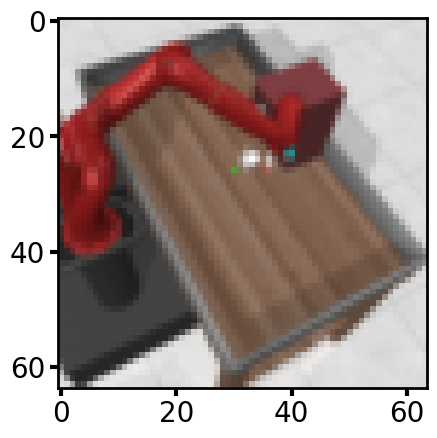

/tmp/ipykernel_2902948/3569954649.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  enc = model.encoder(torch.tensor(render_img).permute(2, 0, 1).unsqueeze(0).to(device))


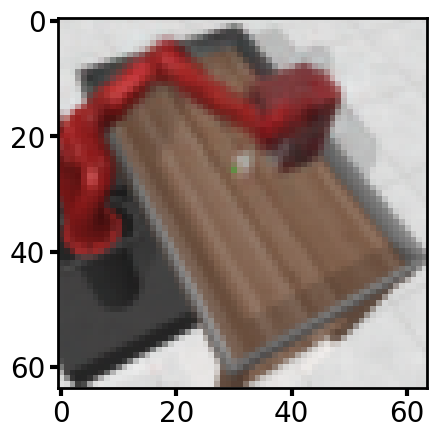

In [78]:
env = gym.make('Meta-World/MT1', env_name=name_to_env["coffee"], render_mode='rgb_array', camera_name='corner3')
obs, _ = env.reset()
render_img = process_image(np.rot90(plt.imread("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/coffee_spill.png")[:, :, :3], k=2) * 255., 'coffee')
print(render_img.shape)
plt.imshow(render_img)
plt.show()

enc = model.encoder(torch.tensor(render_img).permute(2, 0, 1).unsqueeze(0).to(device))
stats = model.post(enc)
mu, log_var = stats.chunk(2, dim=-1)
# log_var = torch.clamp(log_var, min=1e-5, max=1e5)
z = model.reparameterize(mu, log_var)
x_recon, x_recon_uncertainty = model.decoder(z)
recon_img = x_recon.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
plt.imshow(recon_img)
plt.show()
plt.imsave("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/coffee_spill_recon.png", recon_img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.055913467..1.0000002].


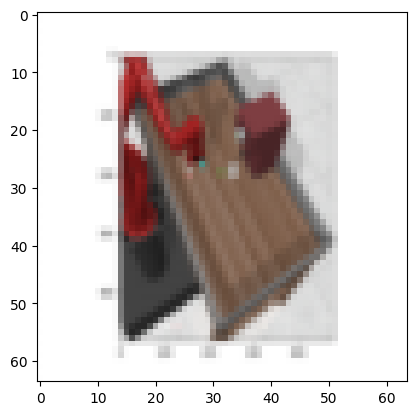

In [ ]:
img = plt.imread("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/coffee_start.png")[:, :, :3]
img = np.rot90(img, k=2)
render_img = process_image(img, 'coffee').permute(2, 0, 1)

# plt.imshow(np.transpose(render_img * 255, (1, 2, 0)))
# plt.show()
# frame_buffer = [render_img.to(device, dtype=torch.float32) for _ in range(3)]

In [80]:
mu, costs, sigma, action_samples = sample_cem(model, frame_buffer)

In [81]:
# Load frames and pick last frame
frames = np.load("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/first_5_frames_data.npy", allow_pickle=True)
# Extract start position from the last frame (first 3 values)
all_trajectories = frames.item()['trajectories'][0]['all_trajectories']
all_trajectories = np.asarray(all_trajectories)

In [104]:
def plot_traj(trajectories, costs, start_marker_pos=None, top_k=None):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Convert to numpy if needed
    costs_np = costs.cpu().numpy() if isinstance(costs, torch.Tensor) else costs
    trajectories_np = [traj.cpu().numpy() if isinstance(traj, torch.Tensor) else traj for traj in trajectories]
    
    # Select top-k if specified
    if top_k is not None:
        top_indices = np.argsort(costs_np)[-top_k:]
        trajectories_np = [trajectories_np[i] for i in top_indices]
        costs_np = costs_np[top_indices]
    
    # Normalize costs to [0, 1]
    costs_norm = (costs_np - costs_np.min()) / (costs_np.max() - costs_np.min() + 1e-8)
    
    # Plot trajectories
    for traj, cost_norm, cost in zip(trajectories_np, costs_norm, costs_np):
        ax.plot(traj[:, 0], traj[:, 1], c=plt.cm.magma(cost_norm), alpha=0.7, linewidth=1.5)
    
    if start_marker_pos is not None:
        ax.scatter(start_marker_pos[0], start_marker_pos[1], c='red', marker='x', s=100, label='Start Position')
    
    # ax.set_xlabel('X Position', fontsize=12)
    # ax.set_ylabel('Y Position', fontsize=12)
    # title = f'Planned Trajectories Colored by Information Gain (top {top_k})' if top_k else 'Planned Trajectories Colored by Information Gain'
    # ax.set_title(title, fontsize=14)
    
    # Add colorbar with proper normalization
    sm = plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=costs_np.min(), vmax=costs_np.max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Information Gain (Cost)')
    
    # ax.legend()
    fig.patch.set_alpha(0.0)  # Transparent background for the figure
    ax.set_facecolor('none')
    ax.axis('off')
    plt.savefig("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/planned_trajectories.png", bbox_inches='tight', pad_inches=0)
    plt.show()

# Usage:
# plot_traj(trajectories, costs, start_marker_pos=start_pos)  # All trajectories
# plot_traj(trajectories, costs, start_marker_pos=start_pos, top_k=50)  # Top 50

In [101]:
costs = np.loadtxt("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/step_costs.txt")

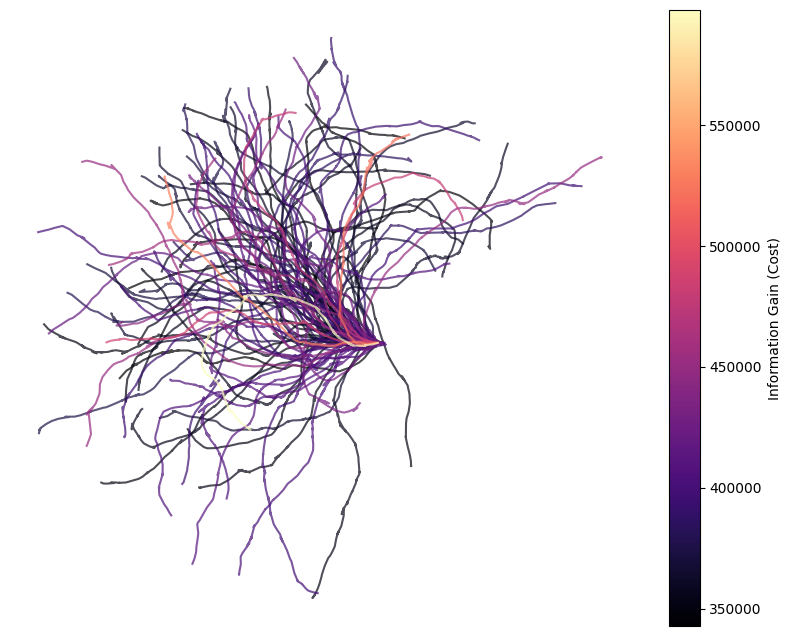

In [105]:
plot_traj(all_trajectories[:, :, :-1], costs, top_k=100)

/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:35: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
/home/ayush/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


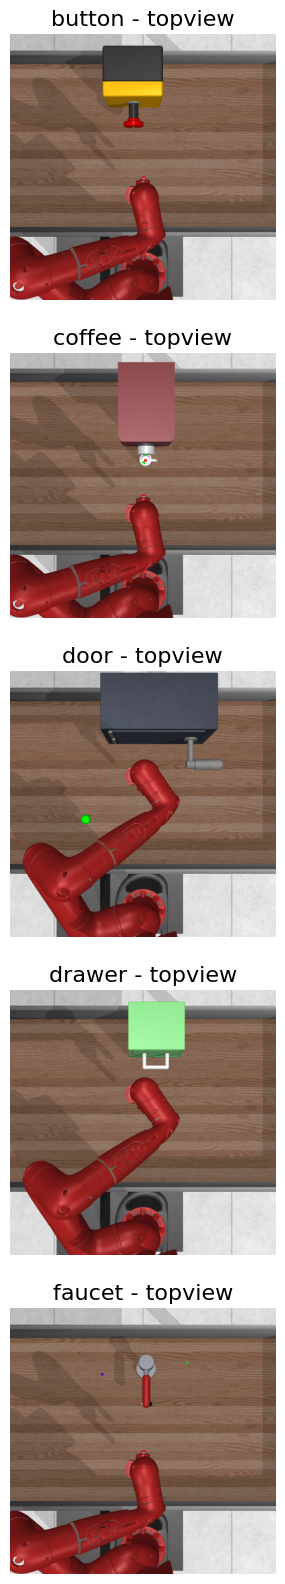

In [5]:
fig, ax = plt.subplots(5, 1, figsize=(4, 20))
for i, env_name in enumerate(['button', 'coffee', 'door', 'drawer', 'faucet']):
    env = gym.make('Meta-World/MT1', env_name=name_to_env[env_name], render_mode='rgb_array', camera_name='topview')
    obs, _ = env.reset(seed=0)
    img = env.render()
    ax[i].imshow(img)
    ax[i].set_title(f'{env_name} - topview', fontsize=16)
    ax[i].axis('off')
plt.axis('off')
plt.show()

In [10]:
print(data['coffee'].keys())

dict_keys(['pixel', 'dynamics', 'random'])


In [94]:
import matplotlib as mpl
# Configure Matplotlib to use LaTeX for text rendering
plt.rcParams['text.usetex'] = False
plt.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts are used
plt.rcParams['ps.fonttype'] = 42   # Ensures TrueType fonts for PostScript output
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Didot'] + plt.rcParams['font.serif']

mpl.rcParams['lines.linewidth'] = 5
mpl.rcParams['lines.markersize'] = 10
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['figure.titlesize'] = 36
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 32
# mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 5
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['xtick.major.pad'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['ytick.major.pad'] = 3
mpl.rcParams['figure.subplot.hspace'] = 0.85
mpl.rcParams["axes.labelpad"] = 5

bw_props = dict(linestyle='-', linewidth=2.5, color='black')
boxplot_kwargs = dict(
    vert=True,
    patch_artist=True,
    widths=0.5,
    whis=[0, 100],
    showfliers=False,
    medianprops=bw_props,
    boxprops=bw_props,
    capprops=bw_props,
    whiskerprops=bw_props,
    flierprops=dict(linestyle='', markersize=10, markeredgewidth=2, color='black'),
    showmeans=False,
    meanline=True
)

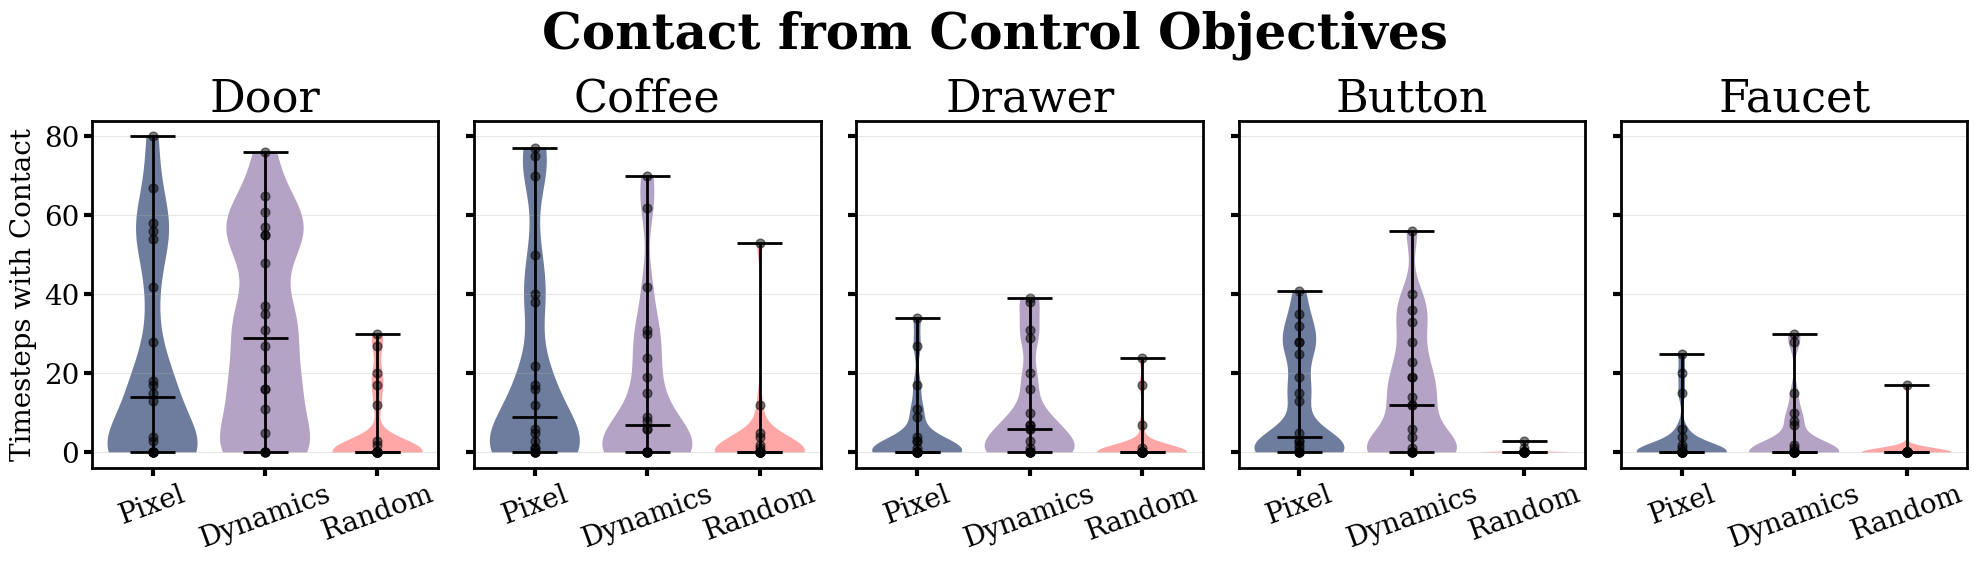

In [95]:
import json
import matplotlib.pyplot as plt
import numpy as np

# env_json = "button"
# with open(f"/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/{env_json}_20.json", "r") as f:
with open(f"/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/contacts_seed_20.json", "r") as f:
    data_20 = json.load(f)

with open(f"/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/contact/contacts_seed_21.json", "r") as f:
    data_21 = json.load(f)
for env in data_20.keys():
    for obj in data_20[env].keys():
        data_20[env][obj].extend(data_21[env][obj])
data = data_20.copy()

environments = ['door', 'coffee', 'drawer', 'button', 'faucet']
objectives = ['pixel', 'dynamics', 'random']
objective_labels = {'random': 'Random', 'pixel': 'Pixel', 'dynamics': 'Dynamics'}
colors = {'random': '#ff8080', 'pixel': '#304674', 'dynamics': '#957dadff'}

# Prepare data for plotting
plot_data = {env: {obj: data[env][obj] for obj in objectives} for env in environments}

fig, axes = plt.subplots(1, len(environments), figsize=(20, 6), sharey=True)

for idx, env in enumerate(environments):
    ax = axes[idx]
    parts = []
    for j, obj in enumerate(objectives):
        values = plot_data[env][obj]
        # Violin plot for each objective
        vp = ax.violinplot(
            values,
            positions=[j],
            showmeans=False,
            showmedians=True,
            showextrema=True,
            widths=0.8,
            bw_method=0.3, points=500
        )
        for pc in vp['bodies']:
            pc.set_facecolor(colors[obj])
            pc.set_alpha(0.7)
        for partname in ('cbars', 'cmedians', 'cmaxes', 'cmins'):
            vp[partname].set_edgecolor('black')
            vp[partname].set_linewidth(2)
        parts.append(vp)
        # bp = ax.boxplot(values,
        #                 vert=True, 
        #                 patch_artist=True, 
        #                 medianprops=bw_props, 
        #                 boxprops=dict(linestyle='-', linewidth=2.5, color='black'), 
        #                 capprops=bw_props, 
        #                 whiskerprops=bw_props, 
        #                 showfliers=False,
        #                 flierprops=dict(linestyle='', markersize=10, markeredgewidth=2, color='black'),
        #                 widths=0.5,
        #                 whis=[0, 100],
        #                 positions=[j],
        #                 showmeans=False,
        #                 # meanprops=mean_props,
        #                 meanline=True)

        # for patch in bp["boxes"]:
        #     patch.set_facecolor(colors[obj])
        #     patch.set_alpha(0.7)
        ax.scatter(
            j * np.ones_like(values),
            values,
            alpha=0.5,
            color='black',
            s=40
        )
    ax.set_xticks(range(len(objectives)))
    ax.set_xticklabels([objective_labels[obj] for obj in objectives], rotation=20)
    ax.set_title(env.capitalize())
    if idx == 0:
        ax.set_ylabel("Timesteps with Contact")
    ax.grid(True, axis='y', alpha=0.3)

# Add a legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors[obj], label=objective_labels[obj], alpha=0.7) for obj in objectives]
# fig.legend(handles=legend_handles, loc='upper right') #, fontsize=14)

plt.suptitle("Contact from Control Objectives", y=0.93) #, fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/sim_vplots.png", bbox_inches='tight', dpi=200)
plt.show()

In [195]:
def generate_biased_diffusion_trajectories(num_trajectories=100, num_steps=50, goal=(10, 10), bias_strength=0.5):
    """
    Generate trajectories using biased diffusion process (RRT-esque).
    
    Args:
        num_trajectories: Number of trajectories to generate
        num_steps: Number of steps per trajectory
        goal: Target position (x, y)
        bias_strength: Strength of bias toward goal (0-1)
    
    Returns:
        trajectories: Array of shape (num_trajectories, num_steps, 2)
    """
    trajectories = []
    dt = 0.2  # Time step
    sigma = 0.5  # Diffusion noise level
    
    for _ in range(num_trajectories):
        traj = np.zeros((num_steps, 2))
        pos = np.array([0.0, 0.0])
        
        for t in range(num_steps):
            # Direction to goal
            direction_to_goal = np.array(goal) - pos
            dist_to_goal = np.linalg.norm(direction_to_goal)
            
            if dist_to_goal > 1e-6:
                direction_to_goal = direction_to_goal / dist_to_goal
            
            # Biased drift
            drift = bias_strength * direction_to_goal
            
            # Random diffusion
            noise = np.random.randn(2) * sigma
            
            # Update position
            pos = pos + drift * dt + noise * np.sqrt(dt)
            traj[t] = pos
        
        trajectories.append(traj)
    
    return np.array(trajectories)

# Generate trajectories
trajectories = generate_biased_diffusion_trajectories(num_trajectories=50, num_steps=50)

In [196]:
costs = np.loadtxt("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/step_costs.txt")
# TODO: make a colorbar based on the range of values from costs, and use it to color the trajectories


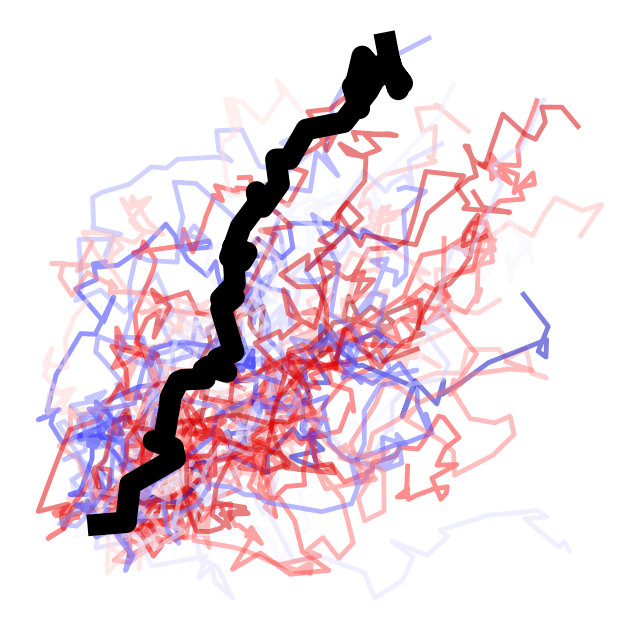

In [199]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# Normalize costs to [0, 1]
norm = Normalize(vmin=costs.min(), vmax=costs.max())
cmap = plt.cm.seismic
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
top_indices = np.argsort(costs)[-len(trajectories):]
top_indices = top_indices[::-1]  # descending order
top_idx = np.where(top_indices < len(trajectories))[0]

# ax.plot(trajectories[:, :, 0].T, trajectories[:, :, 1].T, c=costs[:len(trajectories)], alpha=0.3)
# Plot trajectories colored by cost
for i, traj, cost in zip(range(len(trajectories)), trajectories, costs):
    color = cmap(norm(cost))
    ax.plot(traj[:, 0], traj[:, 1], c=color, alpha=0.5, linewidth=3.5)
    # if i == top_indices[top_idx[1]]:
    #     ax.plot(traj[:, 0], traj[:, 1], c='k', alpha=1.0, linewidth=2.5)

idx_to_plot = 0
ax.plot(trajectories[top_indices[top_idx[idx_to_plot]], :, 0], trajectories[top_indices[top_idx[idx_to_plot]], :, 1], c='k', alpha=1.0, linewidth=15.5)
# Add colorbar
# cbar = plt.colorbar(sm, ax=ax, label='Information Gain (Cost)')
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
plt.axis('off')
plt.savefig("/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/diffuse_pick.png", bbox_inches='tight', pad_inches=0, dpi=150)
plt.show()